# Portfolio Stock Price Prediction with Machine Learning
## **Portfolio**

## Objective
Train machine learning models to predict the stock prices of a portfolio of major technology companies (Apple, Microsoft, Google, Amazon, NVIDIA) using historical data and technical indicators. The goal is to extend single‑equity forecasting into a multi‑asset framework and evaluate performance at both the individual and portfolio levels.

## Approach
This project applies **linear regression** to time‑series data for multiple equities, using lagged closing prices and common technical indicators (Simple Moving Averages and RSI). Each equity is modeled individually, and results are consolidated into portfolio‑level forecasts. Both static (frozen indicators) and dynamic (rolling updates of SMA/RSI) forecasts are compared to illustrate the trade‑off between in‑sample accuracy and out‑of‑sample realism.

## Key Features
- Historical data downloaded via `yfinance` for multiple tickers
- Lag features (1, 2, 3, 5, 10 days) per equity
- Technical indicators (SMA‑5, SMA‑10, RSI‑14)
- Train/test evaluation with RMSE, MAE, R² for each equity
- Forecast visualization (static vs dynamic) for individual assets
- Consolidated portfolio plot showing average forecasts
- Portfolio‑level metrics (RMSE, MAE, R²) comparing static vs dynamic forecasts

## Project Structure
For clarity and progression, this project is organized into two complementary Colab notebooks:
- **Single Equity (Apple):** Focuses on one stock, demonstrating lag features, SMA, RSI, and the comparison between static and dynamic forecasts.
- **Portfolio Forecasting:** Extends the same methodology to multiple equities, highlighting how regression models can be scaled to a portfolio context, with both per‑ticker and consolidated portfolio evaluations.
  - Portfolio consist of: Apple, Microsoft, Amazon, Google and NVDIA

Together, these notebooks provide a step‑by‑step learning path: starting with a single equity model and then expanding to a multi‑asset framework, culminating in portfolio‑level insights.

---


[*********************100%***********************]  1 of 1 completed


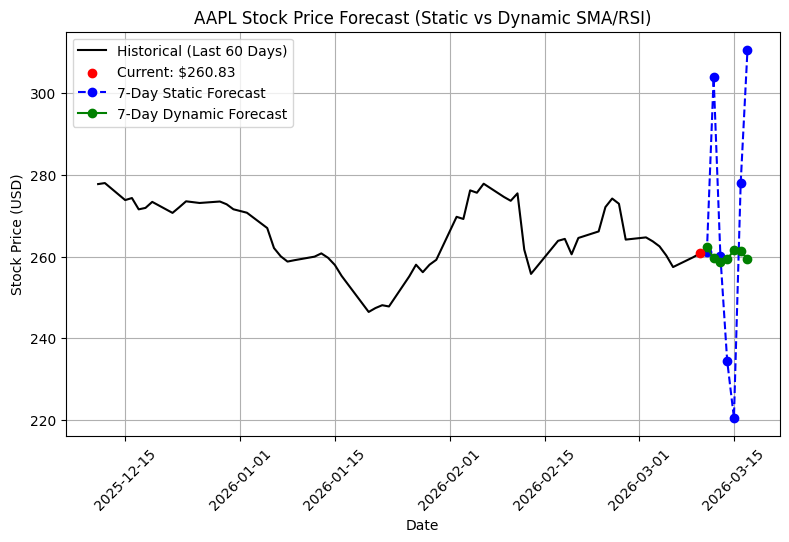

[*********************100%***********************]  1 of 1 completed


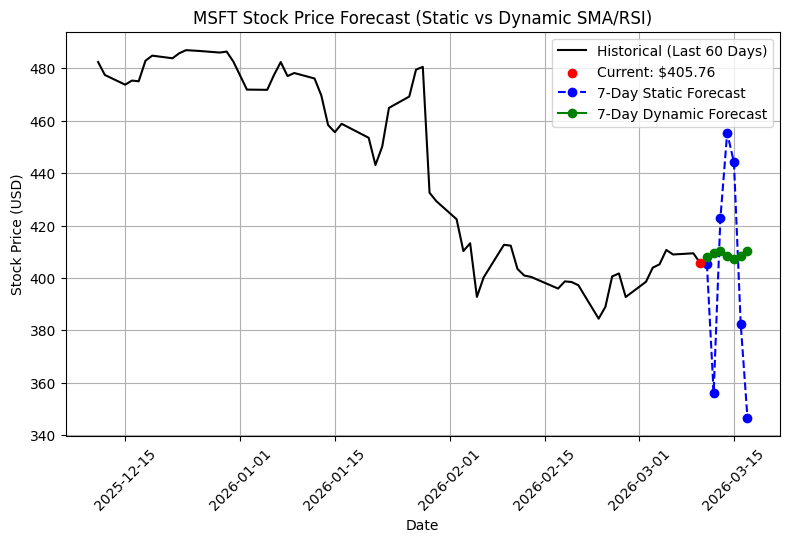

[*********************100%***********************]  1 of 1 completed


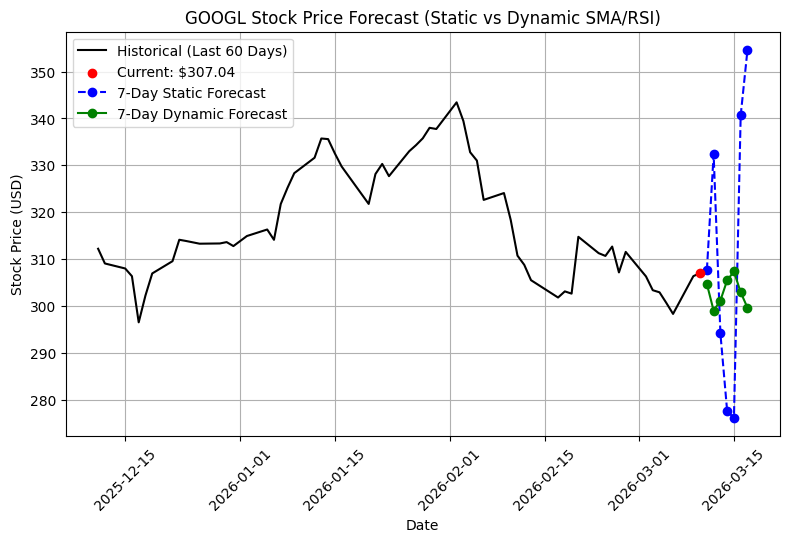

[*********************100%***********************]  1 of 1 completed


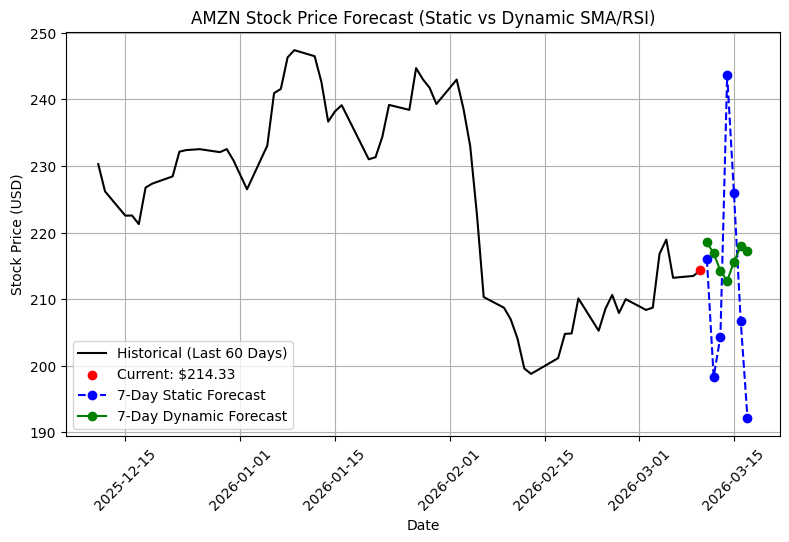

[*********************100%***********************]  1 of 1 completed


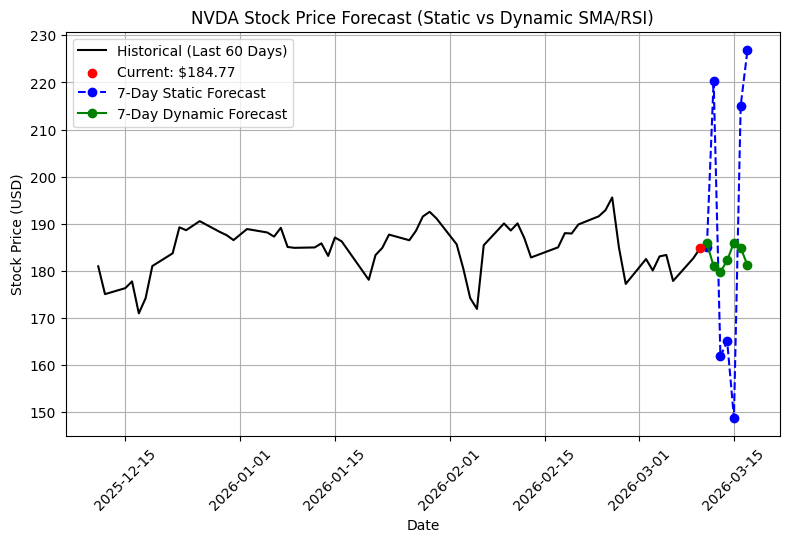


## Current Closing Prices

| Date       | Ticker   |   Price (USD) |
|------------|----------|---------------|
| 2026-03-11 | AAPL     |        260.83 |
| 2026-03-11 | MSFT     |        405.76 |
| 2026-03-11 | GOOGL    |        307.04 |
| 2026-03-11 | AMZN     |        214.33 |
| 2026-03-11 | NVDA     |        184.77 |

## Consolidated Portfolio Forecasts (Next 7 Days, Static SMA/RSI) — starting from 2026-03-11

|       |   AAPL |   MSFT |   GOOGL |   AMZN |   NVDA |
|-------|--------|--------|---------|--------|--------|
| Day 1 | 261.06 | 405.47 |  307.65 | 216.03 | 185.07 |
| Day 2 | 303.9  | 356.19 |  332.33 | 198.34 | 220.37 |
| Day 3 | 260.13 | 422.76 |  294.14 | 204.36 | 161.79 |
| Day 4 | 234.54 | 455.39 |  277.55 | 243.7  | 164.99 |
| Day 5 | 220.56 | 444.1  |  276.15 | 225.96 | 148.75 |
| Day 6 | 278.05 | 382.57 |  340.69 | 206.74 | 215.1  |
| Day 7 | 310.56 | 346.66 |  354.58 | 192.2  | 226.86 |

## Consolidated Portfolio Forecasts (Next 7 Days, Dynamic SMA/RSI) — starting 

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
from tabulate import tabulate

# Portfolio tickers
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA']
today = datetime.today().strftime('%Y-%m-%d')

# Collect results
comparison_metrics_dict = {}
forecasts_static_dict = {}
forecasts_dynamic_dict = {}
current_prices = {}

for ticker in tickers:
    # Step 1: Download historical stock data
    df = yf.download(ticker, start='2015-01-01', end=today, auto_adjust=True)

    # Step 2: Prepare lag features (past closing prices as predictors)
    df['Lag1'] = df['Close'].shift(1)    # Previous day's close
    df['Lag2'] = df['Close'].shift(2)    # Close 2 days ago
    df['Lag3'] = df['Close'].shift(3)    # Close 3 days ago
    df['Lag5'] = df['Close'].shift(5)    # Close 5 days ago
    df['Lag10'] = df['Close'].shift(10)  # Close 10 days ago

    # Step 3: RSI calculation (Relative Strength Index, 14-day)
    df['SMA_5'] = df['Close'].rolling(window=5).mean()   # 5-day simple moving average
    df['SMA_10'] = df['Close'].rolling(window=10).mean() # 10-day simple moving average
    delta = df['Close'].diff()  # Daily price changes
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean() # Average gains
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss  # Relative strength
    df['RSI_14'] = 100 - (100 / (1 + rs))  # RSI formula
    df.dropna(inplace=True)   # Drop rows with NaN values

    # Step 4: Features and target
    X = df[['Lag1', 'Lag2', 'Lag3', 'Lag5', 'Lag10', 'SMA_5', 'SMA_10', 'RSI_14']]
    y = df['Close']

    # Step 5: Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Step 6: Train Linear regression model
    model = LinearRegression()
    model.fit(X_train, y_train)

    # Step 7a: Static Forecast (frozen indicators)
    # Use last available feature vector and roll forward without updating SMA/RSI
    latest_static = X.iloc[-1].values
    future_preds_static = []
    for i in range(7):
        next_pred = model.predict([latest_static])[0]   # Predict next close
        future_preds_static.append(next_pred.item())
        latest_static = np.roll(latest_static, 1)       # Shift lag features
        latest_static[0] = next_pred.item()             # Insert new prediction
    forecasts_static_dict[ticker] = [round(p, 2) for p in future_preds_static]

    # Step 7b: Dynamic Forecast (rolling SMA/RSI)
    # Recalculate SMA and RSI at each step using predicted prices
    latest_prices = df['Close'].iloc[-14:].squeeze().tolist()
    future_preds_dynamic = []
    for i in range(7):
        sma5 = np.mean(latest_prices[-5:])                 # Recompute SMA-5
        sma10 = np.mean(latest_prices[-10:])               # Recompute SMA-10
        deltas = np.diff(latest_prices[-15:])              # Price changes
        gains = np.mean(np.where(deltas > 0, deltas, 0))   # Avg gains
        losses = np.mean(np.where(deltas < 0, -deltas, 0)) # Avg losses
        rs = gains / losses if losses != 0 else np.inf     # Relative strength
        rsi14 = 100 - (100 / (1 + rs))                     # RSI formula

        # Update lag features with latest predicted prices
        lag1, lag2, lag3, lag5, lag10 = latest_prices[-1], latest_prices[-2], latest_prices[-3], latest_prices[-5], latest_prices[-10]
        features = np.array([[lag1, lag2, lag3, lag5, lag10, sma5, sma10, rsi14]])

        next_pred = model.predict(features)[0]         # Predict next close
        future_preds_dynamic.append(next_pred.item())
        latest_prices.append(next_pred.item())         # Append prediction for next iteration
    forecasts_dynamic_dict[ticker] = [round(p, 2) for p in future_preds_dynamic]

    # Step 8: Current price
    current_price = df['Close'].iloc[-1]
    current_prices[ticker] = round(current_price.item(), 2)

    # Step 9: Forecast horizon metrics (last 7 actual closes)
    actual_future = df['Close'].iloc[-7:].values

    # Static metrics
    mse_static = mean_squared_error(actual_future, future_preds_static)
    rmse_static = np.sqrt(mse_static)
    mae_static = mean_absolute_error(actual_future, future_preds_static)
    r2_static = r2_score(actual_future, future_preds_static)

    # Dynamic metrics
    mse_dynamic = mean_squared_error(actual_future, future_preds_dynamic)
    rmse_dynamic = np.sqrt(mse_dynamic)
    mae_dynamic = mean_absolute_error(actual_future, future_preds_dynamic)
    r2_dynamic = r2_score(actual_future, future_preds_dynamic)

    # Store combined comparison
    comparison_metrics_dict[ticker] = {
        "Static RMSE": round(rmse_static, 2),
        "Static MAE": round(mae_static, 2),
        "Static R²": round(r2_static, 4),
        "Dynamic RMSE": round(rmse_dynamic, 2),
        "Dynamic MAE": round(mae_dynamic, 2),
        "Dynamic R²": round(r2_dynamic, 4)
    }

    # Step 10: Plot both static and dynamic forecasts
    current_date = df.index[-1]
    future_dates = pd.date_range(start=current_date + pd.Timedelta(days=1), periods=7)

    plt.figure(figsize=(8, 5))
    plt.plot(df.index[-60:], df['Close'].iloc[-60:], label='Historical (Last 60 Days)', color='black')
    plt.scatter(current_date, current_price.item(), color='red', label=f'Current: ${current_price.item():.2f}', zorder=5)
    plt.plot(future_dates, future_preds_static, marker='o', linestyle='--', color='blue', label='7-Day Static Forecast')
    plt.plot(future_dates, future_preds_dynamic, marker='o', linestyle='-', color='green', label='7-Day Dynamic Forecast')
    plt.title(f'{ticker} Stock Price Forecast (Static vs Dynamic SMA/RSI)')
    plt.xlabel('Date')
    plt.ylabel('Stock Price (USD)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.savefig(f"{ticker.lower()}_forecast_static_vs_dynamic.png", dpi=300, bbox_inches='tight')
    plt.show()

# ---- Consolidated Results ----

# Current prices with run date
run_date = datetime.today().strftime('%Y-%m-%d')
df_current = pd.DataFrame.from_dict(current_prices, orient='index', columns=['Price (USD)'])
df_current.reset_index(inplace=True)
df_current.rename(columns={'index':'Ticker'}, inplace=True)
df_current['Date'] = run_date
print("\n## Current Closing Prices\n")
print(tabulate(df_current[['Date','Ticker','Price (USD)']], headers='keys', tablefmt='github', showindex=False))

# Forecasts tables
df_forecasts_static = pd.DataFrame(forecasts_static_dict)
df_forecasts_static.index = [f"Day {i}" for i in range(1, 8)]
print(f"\n## Consolidated Portfolio Forecasts (Next 7 Days, Static SMA/RSI) — starting from {run_date}\n")
print(tabulate(df_forecasts_static, headers='keys', tablefmt='github'))

df_forecasts_dynamic = pd.DataFrame(forecasts_dynamic_dict)
df_forecasts_dynamic.index = [f"Day {i}" for i in range(1, 8)]
print(f"\n## Consolidated Portfolio Forecasts (Next 7 Days, Dynamic SMA/RSI) — starting from {run_date}\n")
print(tabulate(df_forecasts_dynamic, headers='keys', tablefmt='github'))

# Combined comparison table with aggregate row
df_comparison = pd.DataFrame(comparison_metrics_dict).T

# Add portfolio-level aggregate row (mean across tickers)
aggregate_row = {
    "Static RMSE": round(df_comparison["Static RMSE"].mean(), 2),
    "Static MAE": round(df_comparison["Static MAE"].mean(), 2),
    "Static R²": round(df_comparison["Static R²"].mean(), 4),
    "Dynamic RMSE": round(df_comparison["Dynamic RMSE"].mean(), 2),
    "Dynamic MAE": round(df_comparison["Dynamic MAE"].mean(), 2),
    "Dynamic R²": round(df_comparison["Dynamic R²"].mean(), 4)
}
df_comparison.loc["Portfolio Avg"] = aggregate_row

print("\n## Forecast Comparison (Static vs Dynamic, Last 7 Actual Closes)\n")
print(tabulate(df_comparison, headers='keys', tablefmt='github'))


## Consolidated Portfolio Forecast

In addition to individual asset forecasts, we compute an **equal‑weight portfolio average** to treat the basket of equities as a single “portfolio asset.” This provides a broader view of how the portfolio behaves collectively, smoothing out idiosyncratic movements in individual stocks.

### Key Points
- The portfolio average is calculated by taking the mean of all constituent stock prices (AAPL, MSFT, GOOGL, AMZN, NVDA).
- Historical portfolio value is plotted over the last 60 days, alongside the current portfolio average price.
- Static and dynamic forecasts are generated for the next 7 days and overlaid in a single chart.
- This visualization highlights how diversification reduces volatility compared to individual assets.
- Portfolio‑level metrics (RMSE, MAE, R²) are tabulated to compare static vs dynamic forecasts, confirming that dynamic updates yield significantly lower error.

### Insight
While individual plots reveal each stock’s forecast trajectory, the consolidated portfolio plot demonstrates the collective behavior of the portfolio. It shows that dynamic forecasting not only improves accuracy at the single‑asset level but also produces more stable and interpretable results when applied to the portfolio as a whole.


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


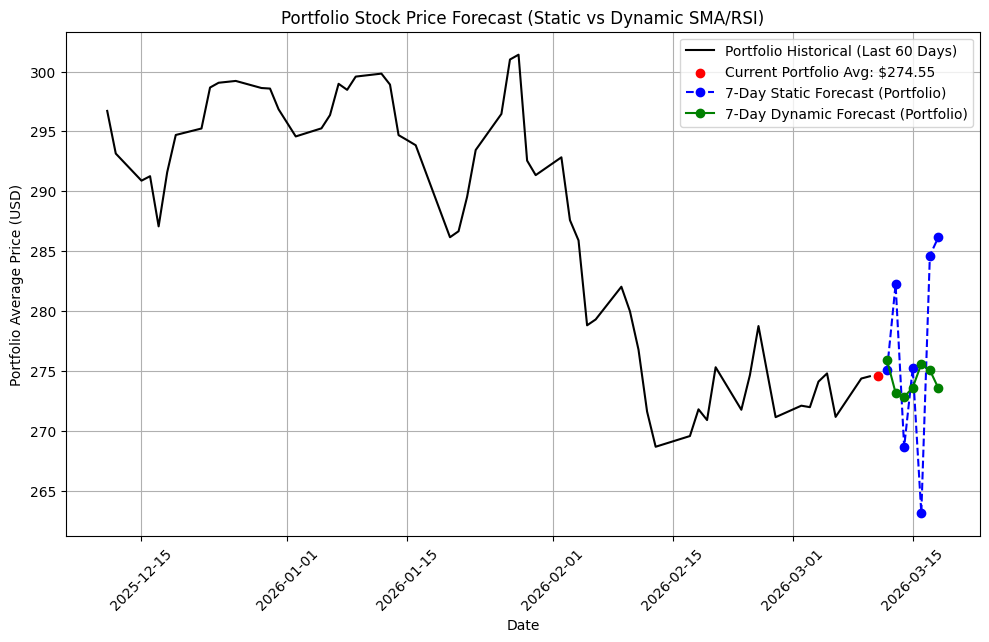

In [3]:
# ---- Consolidated Portfolio Plot ----

# Compute the current portfolio average price (equal-weight across tickers)
portfolio_hist = (df_current.set_index("Ticker")["Price (USD)"]).mean()

# Build equal-weight portfolio forecasts by averaging across tickers
portfolio_static = pd.DataFrame(forecasts_static_dict).mean(axis=1)    # Static forecast series
portfolio_dynamic = pd.DataFrame(forecasts_dynamic_dict).mean(axis=1)  # Dynamic forecast series

# Define forecast horizon dates (next 7 days after run_date)
current_date = datetime.strptime(run_date, "%Y-%m-%d")
future_dates = pd.date_range(start=current_date + pd.Timedelta(days=1), periods=7)

plt.figure(figsize=(10,6))

# Historical portfolio value (last 60 days, equal-weight average of all tickers)
portfolio_prices = pd.concat([
    yf.download(t, start="2025-12-01", end=run_date, auto_adjust=True)["Close"]
    for t in tickers
], axis=1).mean(axis=1)
#Plot historical portfolio average
plt.plot(portfolio_prices.index[-60:], portfolio_prices.values[-60:],
         label="Portfolio Historical (Last 60 Days)", color="black")

# # Mark current portfolio average price as a red dot
plt.scatter(current_date, portfolio_hist, color="red",
            label=f"Current Portfolio Avg: ${portfolio_hist:.2f}", zorder=5)

# Static vs Dynamic forecasts
plt.plot(future_dates, portfolio_static, marker="o", linestyle="--", color="blue",
         label="7-Day Static Forecast (Portfolio)")
plt.plot(future_dates, portfolio_dynamic, marker="o", linestyle="-", color="green",
         label="7-Day Dynamic Forecast (Portfolio)")

plt.title("Portfolio Stock Price Forecast (Static vs Dynamic SMA/RSI)")
plt.xlabel("Date")
plt.ylabel("Portfolio Average Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()


In [4]:
# ---- Consolidated Portfolio Forecast Table ----

# Build DataFrame of forecasts
df_portfolio_forecasts = pd.DataFrame({
    "Date": future_dates.strftime("%Y-%m-%d"),
    "Static Forecast": portfolio_static.values,
    "Dynamic Forecast": portfolio_dynamic.values
})

# Display as a neat table
from tabulate import tabulate
print("\n## Consolidated Portfolio Forecasts (Next 7 Days)\n")
print(tabulate(df_portfolio_forecasts, headers="keys", tablefmt="github", showindex=False))



## Consolidated Portfolio Forecasts (Next 7 Days)

| Date       |   Static Forecast |   Dynamic Forecast |
|------------|-------------------|--------------------|
| 2026-03-12 |           275.056 |            275.88  |
| 2026-03-13 |           282.226 |            273.166 |
| 2026-03-14 |           268.636 |            272.822 |
| 2026-03-15 |           275.234 |            273.598 |
| 2026-03-16 |           263.104 |            275.576 |
| 2026-03-17 |           284.63  |            275.054 |
| 2026-03-18 |           286.172 |            273.542 |


## Portfolio Forecast Metrics

To complement the consolidated portfolio plot, we evaluate forecast accuracy using the portfolio’s average closing prices over the last 7 days. This treats the portfolio as a single “asset” and allows us to compare static vs dynamic forecasts directly.

### Key Points
- Metrics are computed on the equal‑weight portfolio average (mean of AAPL, MSFT, GOOGL, AMZN, NVDA).
- RMSE and MAE measure forecast error magnitudes, while R² indicates explanatory power relative to a baseline.
- Results show that static forecasts produce large errors and highly negative R² values, reflecting poor fit.
- Dynamic forecasts reduce RMSE and MAE substantially, and although R² remains slightly negative (due to short‑horizon volatility), the improvement is clear.

### Insight
The portfolio metrics confirm the same pattern observed at the individual asset level:  
- **Static forecasts** are unstable and not useful for forward prediction.  
- **Dynamic forecasts** provide more realistic and financially meaningful projections, both for single equities and for the portfolio as a whole.  

Together with the consolidated plot, this section demonstrates how diversification smooths volatility and how dynamic indicator updates are essential for robust portfolio forecasting.


In [5]:
# Build portfolio actuals (equal-weight average of last 7 closes)
portfolio_actual = pd.concat([
    yf.download(t, start="2026-02-15", end=run_date, auto_adjust=True)["Close"].iloc[-7:]
    for t in tickers
], axis=1).mean(axis=1).values

# Portfolio forecasts (already computed as averages)
portfolio_static = pd.DataFrame(forecasts_static_dict).mean(axis=1).values
portfolio_dynamic = pd.DataFrame(forecasts_dynamic_dict).mean(axis=1).values

# Compute metrics
metrics_portfolio = {
    "Static RMSE": round(np.sqrt(mean_squared_error(portfolio_actual, portfolio_static)), 2),
    "Static MAE": round(mean_absolute_error(portfolio_actual, portfolio_static), 2),
    "Static R²": round(r2_score(portfolio_actual, portfolio_static), 4),
    "Dynamic RMSE": round(np.sqrt(mean_squared_error(portfolio_actual, portfolio_dynamic)), 2),
    "Dynamic MAE": round(mean_absolute_error(portfolio_actual, portfolio_dynamic), 2),
    "Dynamic R²": round(r2_score(portfolio_actual, portfolio_dynamic), 4)
}

# Tabulate
df_portfolio_metrics = pd.DataFrame([metrics_portfolio], index=["Portfolio"])
print("\n## Portfolio Forecast Comparison (Static vs Dynamic, Last 7 Actual Closes)\n")
print(tabulate(df_portfolio_metrics, headers='keys', tablefmt='github'))


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Portfolio Forecast Comparison (Static vs Dynamic, Last 7 Actual Closes)

|           |   Static RMSE |   Static MAE |   Static R² |   Dynamic RMSE |   Dynamic MAE |   Dynamic R² |
|-----------|---------------|--------------|-------------|----------------|---------------|--------------|
| Portfolio |          8.01 |         7.01 |    -32.6196 |           2.39 |          1.94 |      -1.9849 |


## Closing Note: Portfolio Regression Chapter

This notebook extended linear regression forecasting from a single equity (Apple) to a multi‑asset portfolio of major technology stocks. By modeling each ticker individually and then aggregating into an equal‑weight portfolio, we demonstrated how regression methods scale from single‑asset analysis to portfolio‑level insights.

### Key Outcomes
- **Individual forecasts:** Static vs dynamic plots and metrics for each equity confirmed that dynamic indicator updates consistently reduce error.
- **Consolidated portfolio plot:** Treating the portfolio as a single “asset” produced smoother trajectories, highlighting the diversification effect.
- **Portfolio metrics:** RMSE and MAE dropped sharply under dynamic forecasting, while static forecasts showed unstable behavior and highly negative R² values.

### Insight
Static forecasts fit past data but fail in forward prediction. Dynamic forecasts, with rolling SMA/RSI updates, provide more realistic and financially meaningful projections. At the portfolio level, diversification further stabilizes results, reinforcing the importance of dynamic modeling in practice.

### Next Steps
This completes the **Linear Regression (Static vs Dynamic)** chapter of the roadmap. Future notebooks will expand into:
- **ARIMA** for autoregressive time‑series modeling
- **GARCH** for volatility forecasting
- **Portfolio forecasting with diversified sectors**
- **Advanced ML/DL models** (Random Forests, LSTMs)

Together, these methods will build a comprehensive forecasting framework, starting from regression baselines and progressing toward more sophisticated approaches.
